## 3. Method 2: Positional Embedding of Peaks

### 3.1 Motivation

* Required Reading: https://www.nature.com/articles/s41467-024-49731-x
* Simple hashing and binning ignore relative *m/z* spacing.
* Many deep learning models require dense, continuous representations.

### 3.2 Encoding Strategy

* Apply **sinusoidal positional encoding** to each peak's *m/z* value.
* Each peak is mapped to a **512-dimensional vector**.
* Intensities can be incorporated as additional features or scaling factors.

### 3.3 Applications

* Captures fine-grained relationships between peaks.
* Useful as input to transformer or deep learning architectures for spectral analysis.

![Each m/z value, m_j, is projected into 512 dimensions](CasanovoEncoding.png)

Positional encoding, as outlined in the Casanovo paper. D = 512

Alright. That's outrageously complicated. Let's break that equation down into digestible parts. Do you remember this? It's the equation for creating sine wavelengths given a few values that you might've seen in your high school Algebra class.

$$
y = A\sin\big(B(x - h)\big) + k
$$

$$
\begin{aligned}
\text{Amplitude} &= |A|, \\
\text{Midline} &= y=k, \\
\text{Period} &= \frac{2\pi}{|B|}\ \text{ (or } \frac{360^\circ}{|B|}\text{)}, \\
\text{Phase shift} &= 
\begin{cases}
\text{right } h & \text{if } (h\leq0),\\
\text{left } h & \text{if } (h\geq).
\end{cases}
\end{aligned}
$$

### Numerical Example
Consider a sine wave more relevant to our usecase: $\sin(x/((0.001/2\pi)(10,000/0.001)^{1/2}))$. We can calculate our period as:
$$
\text{Period} =  2\pi/(B) \text{ where } B = 1/((0.001/2\pi)(10,000/0.001)^{1/2}) = 2\pi\times(0.001/2\pi)\times(3162.27766017) = 3.162\dots
$$

So, this sine wave goes through one crest and one trough till it hits $x$ again. I.e. the wave starts at, say $x = 0$, and "restarts" at $x = 153.90\dots$. You might recall crest -> crest being a period, or trough -> trough being a period.

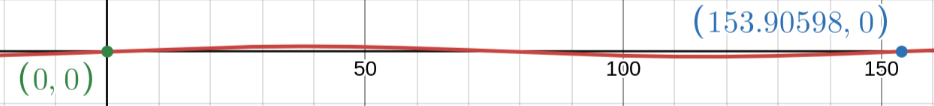


For the second time, I'll throw something at you without expecting you to understand any of it.Now imagine an arbitrary list of numbers spanning from $0.001$ to $10000$, increasing exponentially. This list contains exactly **256 values** - we'll call them our **wavelengths** $\lambda_i$ where i $\in I$ is the index set from 1 through 256. Take this for granted for now, and we'll slowly build up rationale for this list. So thus far, we have: $\lambda = [0.001, \dots, 10000]$. 


### Casanovo intuition
In our toy example with period $153.90\dots$, the wavelength determines **how quickly** the sine wave oscillates. In casanovo's encoding, we don't just use one wave, we use, usually, 256 different wavelengths. We set our minimum and maximum wavelengths to 0.001 and 10000 respectively. So, our period would be $2\pi*\text{wavelength}$ again. 

Let's plot this.


 <!-- $(\lambda_{min}/2\pi (\lambda_{max}/\lambda_{min})^{\dots})$ -->



## Understanding the Fine-to-Coarse Multi-Scale Encoding

Remember our toy example with period $153.90\dots$? The wavelength determines **how quickly** the sine wave oscillates. 

In Casanovo's encoding, we don't use just *one* wavelength - we use **many** (256 different ones), creating a multi-scale representation.

### Coarse (Low-Resolution) Wavelengths

For **large wavelengths** (like $\lambda = 10000$), the sine wave completes very slowly across the m/z range (since $\text{period} = 2\pi\times\lambda$ ):

$$
f(m_j) = \sin\left(\frac{m_j}{\lambda_{\text{large}}}\right)
$$

If $m_j$ ranges from 0 to 1000, and $\lambda_{\text{large}} = 10000$, then:
- At $m_j = 100$: $\sin(0.01) \approx 0.01$
- At $m_j = 200$: $\sin(0.02) \approx 0.02$
- At $m_j = 5000$: $\sin(0.5) \approx 0.48$

These values change *slowly*. Two peaks with $m_j = 100$ and $m_j = 200$ produce nearly identical encodings in this dimension. **They can't distinguish fine details.**

### Fine (High-Resolution) Wavelengths

For **small wavelengths** (like $\lambda = 0.001$), the sine wave oscillates rapidly:

$$
f(m_j) = \sin\left(\frac{m_j}{\lambda_{\text{small}}}\right)
$$

If $m_j$ ranges from 0 to 1000, and $\lambda_{\text{small}} = 0.001$, then:
- At $m_j = 100$: $\sin(100,000) \approx$ some value in $[-1, 1]$
- At $m_j = 100.0001$: $\sin(100,000.1) \approx$ very different value

These values change *rapidly*. Even tiny differences in m/z produce vastly different encodings. **They capture fine details.**

### Why This Matters for Mass Spectrometry

In proteomics, you care about:
- **Coarse differences**: Is peak A fundamentally different from peak B? (e.g., m/z 100 vs m/z 500)
- **Fine differences**: Are these two peaks isotope variants or instrument noise? (e.g., m/z 1000 vs m/z 1000.1)

By encoding with both fine and coarse wavelengths, Casanovo creates a representation that captures *both* structural information and precise localization simultaneously.

## Breaking Down the Formula

Let's start simple: we'll focus on just the sine component of the piecewise equation.

### The Core Equation

For each wavelength, we apply the following transformation:

$$
f_i(m_j) = \sin\left(\frac{m_j}{\lambda_i}\right) \quad \text{for } i < 256
$$

where:
- $m_j$ is the $j$-th peak's $m/z$ value
- $\lambda_i$ is the $i$-th wavelength

### The Full Encoding

In this abstraction, We have **512 dimensions** to encode each peak:

```python
for i in range(dimensions / 2):          # First 256 dimensions: sine
    for j in spectrum_peak_list:
        encoding[i][j] = sin(m_j / wavelength[i])

for i in range(dimensions / 2, dimensions):  # Next 256 dimensions: cosine
    for j in spectrum_peak_list:
        encoding[i][j] = cos(m_j / wavelength[i - 256]) 
        # note: we still only consider wavelengths [0 -> 256], just from encoding[256->512][j]
```


In [ ]:
# Demonstrate the fine-to-coarse intuition numerically
print("=" * 70)
print("FINE VS COARSE: How Different Wavelengths Respond to m/z Changes")
print("=" * 70)

# Generate wavelengths (same as Casanovo)
wavelengths = make_wavelengths_casanovo(512)

# Pick a small wavelength (fine) and a large wavelength (coarse)
fine_idx = 10  # One of the first few
coarse_idx = 240  # One of the last few

fine_wavelength = wavelengths[fine_idx]
coarse_wavelength = wavelengths[coarse_idx]

print(f"\nFINE wavelength (index {fine_idx}): {fine_wavelength:.6f}")
print(f"COARSE wavelength (index {coarse_idx}): {coarse_wavelength:.6f}")

# Test two nearby m/z values
m_z_1 = 1000.0
m_z_2 = 1000.1  # Only 0.1 apart (isotope-like difference)

# Compute encoding values for both wavelengths
fine_enc_1 = np.sin(m_z_1 / fine_wavelength)
fine_enc_2 = np.sin(m_z_2 / fine_wavelength)
coarse_enc_1 = np.sin(m_z_1 / coarse_wavelength)
coarse_enc_2 = np.sin(m_z_2 / coarse_wavelength)

print(f"\n--- Two nearby peaks: m/z {m_z_1} vs m/z {m_z_2} ---")
print(f"\nFINE encoding dimension [{fine_idx}]:")
print(f"  At m/z {m_z_1}: {fine_enc_1:+.6f}")
print(f"  At m/z {m_z_2}: {fine_enc_2:+.6f}")
print(f"  DIFFERENCE: {abs(fine_enc_2 - fine_enc_1):.6f}  ← LARGE! Can distinguish them")

print(f"\nCOARSE encoding dimension [{coarse_idx}]:")
print(f"  At m/z {m_z_1}: {coarse_enc_1:+.6f}")
print(f"  At m/z {m_z_2}: {coarse_enc_2:+.6f}")
print(f"  DIFFERENCE: {abs(coarse_enc_2 - coarse_enc_1):.6f}  ← TINY! Can't distinguish them")

# Now test two far-apart m/z values
m_z_3 = 100.0
m_z_4 = 600.0  # 500 apart (very different peaks)

fine_enc_3 = np.sin(m_z_3 / fine_wavelength)
fine_enc_4 = np.sin(m_z_4 / fine_wavelength)
coarse_enc_3 = np.sin(m_z_3 / coarse_wavelength)
coarse_enc_4 = np.sin(m_z_4 / coarse_wavelength)

print(f"\n--- Two distant peaks: m/z {m_z_3} vs m/z {m_z_4} ---")
print(f"\nFINE encoding dimension [{fine_idx}]:")
print(f"  At m/z {m_z_3}: {fine_enc_3:+.6f}")
print(f"  At m/z {m_z_4}: {fine_enc_4:+.6f}")
print(f"  DIFFERENCE: {abs(fine_enc_4 - fine_enc_3):.6f}  ← Saturated, oscillates wildly")

print(f"\nCOARSE encoding dimension [{coarse_idx}]:")
print(f"  At m/z {m_z_3}: {coarse_enc_3:+.6f}")
print(f"  At m/z {m_z_4}: {coarse_enc_4:+.6f}")
print(f"  DIFFERENCE: {abs(coarse_enc_4 - coarse_enc_3):.6f}  ← CLEAR DIFFERENCE! Can distinguish them")

print("\n" + "=" * 70)
print("KEY TAKEAWAY:")
print("  • FINE wavelengths (small λ): Best at distinguishing SIMILAR peaks")
print("  • COARSE wavelengths (large λ): Best at distinguishing DIFFERENT peaks")
print("  • Using BOTH: Capture structure at ALL scales simultaneously")
print("=" * 70)


In [ ]:
import numpy as np
from pyteomics import mzml
import spectrum_utils.plot as sup
import spectrum_utils.spectrum as sus
import pandas as pd
import matplotlib.pyplot as plt
from typing import Tuple, Dict
from functools import lru_cache

In [ ]:
def make_wavelengths_casanovo(d_model: int, lambda_min: float = 0.001, lambda_max: float = 10000) -> np.ndarray:
    """
    Generate wavelengths following the Casanovo formula:
    λ_i = (λ_min / 2π) * (λ_max / λ_min)^(i / (d_sin - 1))
    
    Args:
        d_model = number of sin/cos pairs to consider.
        lambda_min: minimum wavelength (default: 0.001, as in Casanovo)
        lambda_max: maximum wavelength (default: 10000, as in Casanovo)
    
    Returns: Array of d_model // 2 wavelengths
    """
    # d_model must be divisible by 2.
    wavelengths = np.zeros(d_model // 2)
    for i in range(d_model//2):
        wavelengths[i] = (lambda_min / (2 * np.pi)) * (lambda_max / lambda_min) ** (i / (d_model//2 - 1))
    display("wavelengths:", wavelengths)
    return wavelengths

In [ ]:
# Define positional encoding function used by Casanovo
# This function takes in 1 m/z value and returns a 512-dimensional positional encoding vector
# (this feels sort of like a reverse Fourier transform)
def positional_encoding(m_z, d_model = 512, lambda_min = 0.001, lambda_max = 10000):
    encoding = np.zeros(d_model)
    d_sin = int(d_model/2)
    d_cos = d_model - d_sin
    for d in range(d_sin):
        encoding[d] = np.sin(m_z / ( (lambda_min / (2 * np.pi) ) * (lambda_max / lambda_min)**(d/(d_sin - 1))))
    for d in range(d_sin, d_model):
        encoding[d] = np.cos(m_z / ( (lambda_min / (2 * np.pi) ) * (lambda_max / lambda_min)**((d - d_sin ) / (d_cos - 1))))
    return encoding


In [ ]:
encode_1 = positional_encoding(1000)
encode_2 = positional_encoding(1000.1)
encode_3 = positional_encoding(126.1277)
for i in range(50,2000):
    positional_encoding(i)
display(np.dot(positional_encoding(1000),(positional_encoding(1000.1))), "and", np.dot(positional_encoding(1000),positional_encoding(126.127)))

# plot the encodings as three scatter plots,

# Set the figure size before creating subplots
plt.figure(figsize=(12, 10))

plt.subplot(3, 1, 1)
plt.scatter(range(len(encode_1)), encode_1)
plt.title("Positional Encoding - 1000 m/z")
plt.xlabel("Dimension (i)")
plt.ylabel("Value")

plt.subplot(3, 1, 2)
plt.scatter(range(len(encode_2)), encode_2)
plt.title("Positional Encoding - 1000.1 m/z")
plt.xlabel("Dimension (i)")
plt.ylabel("Value")

plt.subplot(3, 1, 3)
plt.scatter(range(len(encode_3)), encode_3)
plt.title("Positional Encoding - 126.128 m/z")
plt.xlabel("Dimension (i)")
plt.ylabel("Value")

plt.tight_layout()
plt.show()


I only halfway understand what's going on here, so the following explanation should be taken with a grain of salt

The positional encoding attempts to capture both high-resolution information and low-resolution information.

Dimensions ~200-255 and ~450-500 capture low resolution information. They will only differ if there is a large m/z difference between the encoded values.

Dimensions 0-50 and 256-300 encoded high resolution information. They change even if the m/z values are very close together

In [ ]:
# for encode_1 and encode_2, plot the values from 200 to 255
# and calculate the cosine similarity between the two
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(range(200, 256), encode_1[200:256])
plt.title("Positional Encoding - 1000 m/z (200-255)")
plt.xlabel("Dimension (i)")
plt.ylabel("Value")

plt.subplot(1, 2, 2)
plt.scatter(range(200, 256), encode_2[200:256])
plt.title("Positional Encoding - 1000.1 m/z (200-255)")
plt.xlabel("Dimension (i)")
plt.ylabel("Value")

plt.tight_layout()
plt.show()
from sklearn.metrics.pairwise import cosine_similarity

# Calculate cosine similarity between the two encodings
cosine_sim = cosine_similarity([encode_1[200:256]], [encode_2[200:256]])
print("Cosine Similarity (1000 m/z vs 1000.1 m/z):", cosine_sim[0][0])

In [ ]:
# Repeat the above plots and calculations, but this time only consider the range from 0 to 56
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(range(0, 57), encode_1[0:57])
plt.title("Positional Encoding - 1000 m/z (0-56)")
plt.xlabel("Dimension (i)")
plt.ylabel("Value")

plt.subplot(1, 2, 2)
plt.scatter(range(0, 57), encode_2[0:57])
plt.title("Positional Encoding - 1000.1 m/z (0-56)")
plt.xlabel("Dimension (i)")
plt.ylabel("Value")

plt.tight_layout()
plt.show()

# Calculate cosine similarity between the two encodings
cosine_sim = cosine_similarity([encode_1[0:57]], [encode_2[0:57]])
print("Cosine Similarity (1000 m/z vs 1000.1 m/z):", cosine_sim[0][0])